# 02. 複数 dataset の同時フィット (目標 3)

NinjaSat の「軌道ごとのスキャン」のように、カバレッジの違う複数観測を `DataList` に並べて
**1つのモデルで同時フィット**できます。各観測は独立の `ForwardFoldingLike` プラグインです。

In [1]:
import logging; logging.disable(logging.INFO)
import numpy as np
import matplotlib.pyplot as plt

from astromodels import Model, PointSource, Powerlaw
from threeML import DataList, JointLikelihood
from Toy3MLplugin import simulate_counts, BackgroundComponent, make_folded_response
from Toy3MLplugin.toy.scanner import ToyScanLike, toy_observation

E_EDGES = np.array([2.0, 10.0]); FOV_SIGMA = 3.0

def two_sources(KA, KB):
    a = PointSource("SRC_A", l=6.0,  b=0.0, spectral_shape=Powerlaw(K=KA, index=-2.0))
    b = PointSource("SRC_B", l=18.0, b=0.0, spectral_shape=Powerlaw(K=KB, index=-2.0))
    for s in (a, b):
        s.spectrum.main.Powerlaw.index.free = False
        s.position.l.free = False; s.position.b.free = False
    return Model(a, b)

truth = two_sources(1.0, 0.5)

18:48:18 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=6778018;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=6778019;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=6778025;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=6778026;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=6778033;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=6778034;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

18:48:18 WARNING   WARNINGs here are NOT errors                                                      ]8;id=6778041;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=6778042;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#45\45]8;;\

         WARNING   but are inform you about optional packages that can be installed                  ]8;id=6778048;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=6778049;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#46\46]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=6778084;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=6778085;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=6778092;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=6778093;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=6778099;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=6778100;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=6778105;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=6778106;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=6778111;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=6778112;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

In [2]:
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

### 3軌道(カバレッジ・露出が異なる)を作る。各軌道でレスポンスを畳み込む。

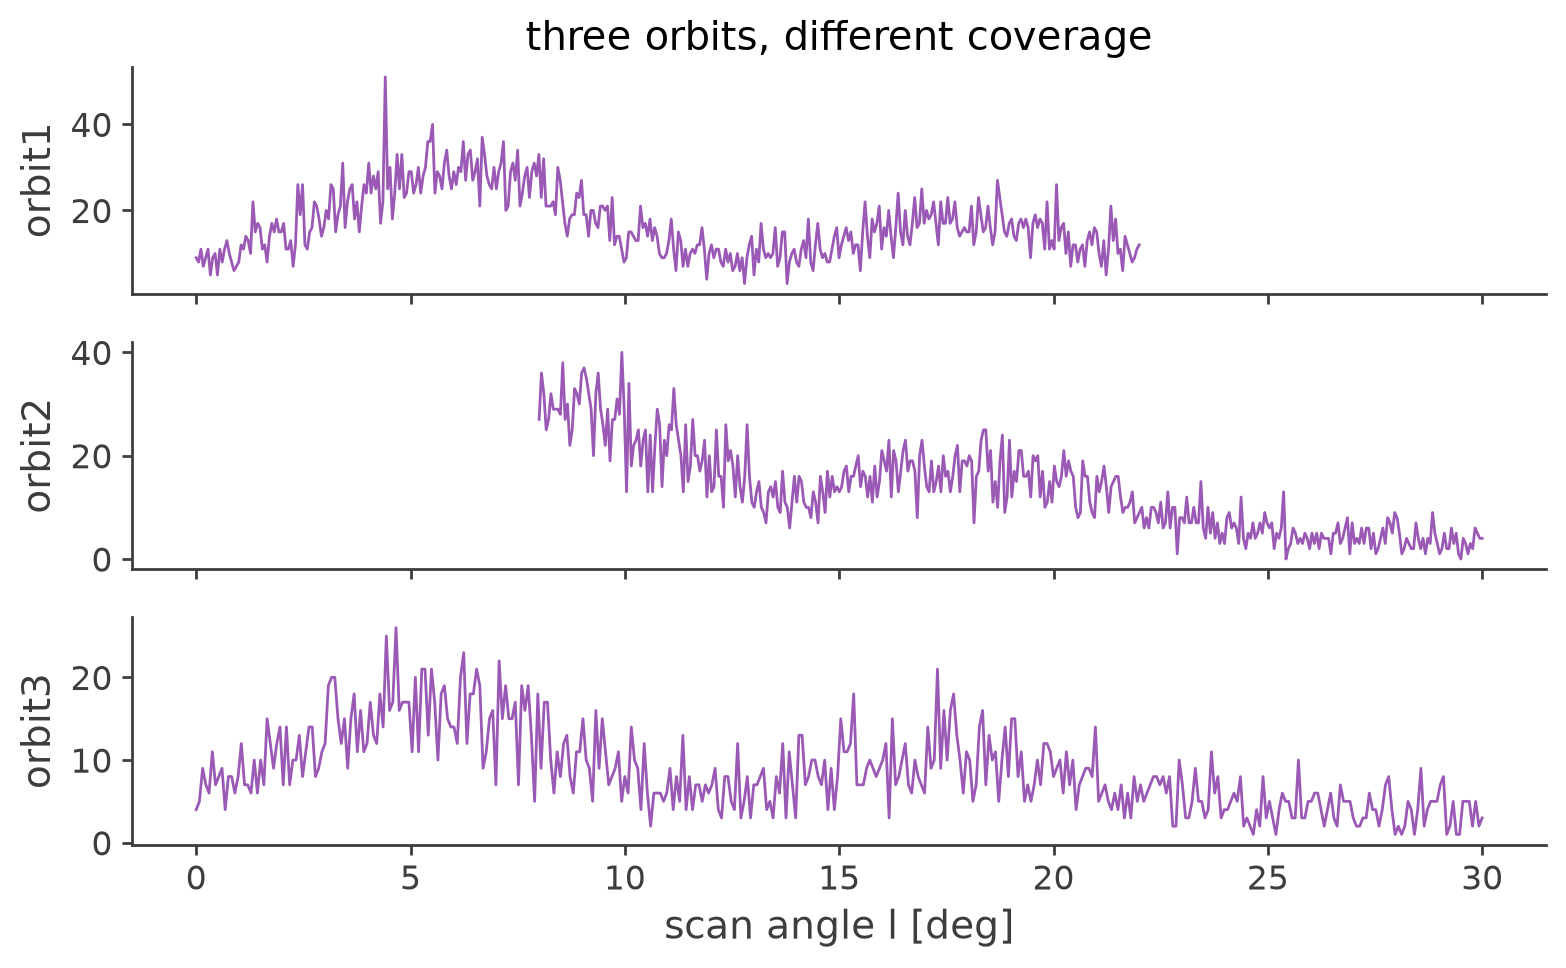

In [3]:
def orbit_plugin(name, lo, hi, dwell, seed):
    R, sky_l, orbit = make_folded_response((lo, hi), n_t=400, dwell=dwell,
                                           energy_edges=E_EDGES, fov_sigma_deg=FOV_SIGMA)
    n = orbit["l"].size
    bkg = lambda: [BackgroundComponent("inst", np.ones(n), value=4.0)]
    sim = ToyScanLike(name, toy_observation(np.zeros(n), R, sky_l, orbit), E_EDGES, backgrounds=bkg())
    data = simulate_counts(sim, truth, np.random.default_rng(seed))
    p = ToyScanLike(name, toy_observation(data, R, sky_l, orbit), E_EDGES, backgrounds=bkg())
    return p, orbit["l"], data

orbits = [orbit_plugin("orbit1", 0, 22, 120.0, 1),
          orbit_plugin("orbit2", 8, 30, 120.0, 2),
          orbit_plugin("orbit3", 0, 30, 60.0, 3)]

fig, ax = plt.subplots(3, 1, figsize=(8,5), sharex=True)
for (p, l, data), a in zip(orbits, ax):
    a.plot(l, data, lw=1); a.set_ylabel(p.name)
ax[-1].set_xlabel("scan angle l [deg]"); ax[0].set_title("three orbits, different coverage")
plt.tight_layout(); plt.show()

### DataList に束ねて同時フィット

In [4]:
plugins = [p for (p, _, _) in orbits]
start = two_sources(0.2, 0.2)
jl = JointLikelihood(start, DataList(*plugins)); jl.set_minimizer("minuit")
_ = jl.fit()
print(f"K(SRC_A) = {start.SRC_A.spectrum.main.Powerlaw.K.value:.3f}  (真 1.0)")
print(f"K(SRC_B) = {start.SRC_B.spectrum.main.Powerlaw.K.value:.3f}  (真 0.5)")

Best fit values:

,result,unit
parameter,,
SRC_A.spectrum.main.Powerlaw.K,(9.85 +/- 0.18) x 10^-1,1 / (keV s cm2)
SRC_B.spectrum.main.Powerlaw.K,(5.16 +/- 0.14) x 10^-1,1 / (keV s cm2)
orbit1_bkg_inst_norm,4.03 +/- 0.27,
orbit2_bkg_inst_norm,4.10 +/- 0.18,
orbit3_bkg_inst_norm,3.86 +/- 0.15,


Correlation matrix:

1.00,0.40,-0.59,-0.37,-0.33
0.40,1.00,-0.60,-0.53,-0.36
-0.59,-0.60,1.00,0.39,0.29
-0.37,-0.53,0.39,1.00,0.23
-0.33,-0.36,0.29,0.23,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
orbit1,-12920.229175
orbit2,-9439.009205
orbit3,-4417.188237
total,-26776.426617


Values of statistical measures:

,statistical measures
AIC,-53542.802983
BIC,-53517.402850


K(SRC_A) = 0.985  (真 1.0)
K(SRC_B) = 0.516  (真 0.5)
